# Temporal Rebinning: 6-hourly HiRO-ACE -> 4h Daily Bins

Rebins HiRO-ACE's native 6-hourly (00/06/12/18) temperature and
precipitation onto the six four-hour daily bins
(`msm_a_temp_4h_bin_0..5` / `garadar_prcp_4h_bin_0..5`) that
`hydro/exp_helpers.py`'s dynamic forcing convention expects (see
`hydro/modified_code/Analysis.ipynb`'s `dynamic_inp.zarr`).

Bins are **end-labeled**: bin `N`'s hour value is the *end* of its 4h
window (bin 0 -> `(0h, 4h]`, ..., bin 5 -> `(20h, 24h]`), matching
HiRO-ACE precipitation's confirmed convention (see below), used
consistently for temperature too.

Two methods, chosen per-variable on confirmed physical grounds:

- **Temperature -- `rebin_temperature_linear`**: ACE2S outputs
  **instantaneous state snapshots** at each 6-hourly timestamp, not window
  averages (confirmed). So this *samples* the exact linear interpolant
  through the 6-hourly knots at each bin's end hour -- an exact copy where
  that hour lands on a native knot (hours 12 and 24), linear interpolation
  otherwise. An earlier version of this computed a bin *mean* instead,
  which is wrong for a snapshot field -- see the sanity-check section below
  for why that matters.
- **Precipitation -- `rebin_precip_conservative`**: HiRO-ACE precip is a
  genuine 6-hour window-*mean* rate, end-labeled (the value at hour `t`
  represents the mean rate over `(t-6h, t]`, confirmed -- standard NWP/ERA5
  convention for autoregressive step outputs). Redistributes that rate onto
  4h target bins by exact time-overlap fraction, normalized by **target**
  bin duration -- see the mass-conservation section below for why
  normalizing by source duration instead (an easy mistake) silently loses
  ~33% of total mass.

**Runs on the full grid, before `catchment_weighting`'s spatial
area-weighted averaging** -- deliberately, even though both methods here
happen to be linear (and would, in principle, commute with the spatial
averaging). The ordering isn't a shortcut that relies on that: a future
non-linear rebinning method must be able to replace either function here
without requiring any change to `catchment_weighting`, so this step always
operates on the gridded field and the catchment step always runs after.
Also deliberately kept downstream of `processing/temp_downscaling`'s
lapse-rate correction (not upstream, on the raw ACE2S field) -- that
correction is affine and time-invariant, so the two orderings are
mathematically identical, and operating on the already-validated
`TMP2m_corrected.zarr` avoids re-touching that module for an input shape
it's never been tested against.

Output keeps a `time` dim (now daily) plus a new `bin` dim (four-hour-bin
*end* hour: 4, 8, 12, 16, 20, 24) alongside whatever else was already
there (`lat`/`lon`, and `ensemble` for precipitation) -- so
`catchment_weighting` can consume this notebook's output directly with
zero changes, since it already treats any non-lat/lon dim as pass-through.

## Setup

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import temporal_binning_lib as tbl

## Weight matrices

Pure functions of bin/knot geometry (no data) -- worth looking at directly
before trusting them on real data. Both matrices' rows sum to 1 (each
target bin is a proper weighted average / conservative redistribution of
its contributing source knots). Note `TEMP_WEIGHTS` now has exact `1`
entries at bins 12 and 24 (point-sample, exact copy at a native knot) --
not the case for the old bin-mean version.

In [2]:
print("TEMP_WEIGHTS (6 bins, end-labeled hours [4,8,12,16,20,24] x 5 knots at local hours [0,6,12,18,24]):")
print(np.round(tbl.TEMP_WEIGHTS, 4))
print("row sums:", tbl.TEMP_WEIGHTS.sum(axis=1))

print("\nPRECIP_WEIGHTS (6 bins x 4 windows ending at local hours [6,12,18,24]):")
print(np.round(tbl.PRECIP_WEIGHTS, 4))
print("row sums:", tbl.PRECIP_WEIGHTS.sum(axis=1))

print("\nbin coordinate (end hour):", tbl.BIN_END_HOURS)

TEMP_WEIGHTS (6 bins, end-labeled hours [4,8,12,16,20,24] x 5 knots at local hours [0,6,12,18,24]):
[[0.3333 0.6667 0.     0.     0.    ]
 [0.     0.6667 0.3333 0.     0.    ]
 [0.     0.     1.     0.     0.    ]
 [0.     0.     0.3333 0.6667 0.    ]
 [0.     0.     0.     0.6667 0.3333]
 [0.     0.     0.     0.     1.    ]]
row sums: [1. 1. 1. 1. 1. 1.]

PRECIP_WEIGHTS (6 bins x 4 windows ending at local hours [6,12,18,24]):
[[1.  0.  0.  0. ]
 [0.5 0.5 0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0. ]
 [0.  0.  0.5 0.5]
 [0.  0.  0.  1. ]]
row sums: [1. 1. 1. 1. 1. 1.]

bin coordinate (end hour): [ 4  8 12 16 20 24]


## Temperature: rebin the real HiRO-ACE series

`TMP2m_corrected.zarr` is 40 steps (10 days x 4/day, Aug 1-10 2023),
already lapse-rate DEM-corrected onto HiRO's 3km grid.

In [3]:
TEMP_ZARR = "/Users/valentin/Desktop/UNRISK/Projects/Climate_models/HiroACE/local/temperature_downscaling/hiro/TMP2m_corrected.zarr"

temp_ds = xr.open_zarr(TEMP_ZARR)
temp_da = temp_ds["TMP2m"].load()
print(temp_da.dims, temp_da.shape)
print(temp_da["time"].values[:6])

('time', 'lat', 'lon') (40, 704, 736)
[cftime.DatetimeJulian(2023, 8, 1, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeJulian(2023, 8, 1, 6, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeJulian(2023, 8, 1, 12, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeJulian(2023, 8, 1, 18, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeJulian(2023, 8, 2, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeJulian(2023, 8, 2, 6, 0, 0, 0, has_year_zero=False)]


`valid_day_starts` needs one step of lookahead past each day's own 4
samples (that day's last two bins need the *following* day's 00:00 knot --
see docs/temporal_binning.md), so with a series ending exactly at Aug 10
18:00, Aug 10 itself can't be fully rebinned -- expect 9 valid days out of
10, not 10.

In [4]:
day_start_idx, day_dates = tbl.valid_day_starts(temp_da["time"].values)
print(f"{len(day_start_idx)} valid days (out of 10 calendar days in the series):")
print(day_dates)

9 valid days (out of 10 calendar days in the series):
[cftime.DatetimeJulian(2023, 8, 1, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 2, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 3, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 4, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 5, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 6, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 7, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 8, 0, 0, 0, 0, has_year_zero=False), cftime.DatetimeJulian(2023, 8, 9, 0, 0, 0, 0, has_year_zero=False)]


In [5]:
temp_binned = tbl.rebin_temperature_linear(temp_da)
print(temp_binned.dims, temp_binned.shape)
temp_binned

('time', 'bin', 'lat', 'lon') (9, 6, 704, 736)


<xarray.DataArray 'TMP2m' (time: 9, bin: 6, lat: 704, lon: 736)> Size: 224MB
array([[[[301.33252096, 301.37549867, 301.41847638, ..., 302.27884508,
          302.28800039, 302.29715571],
         [301.31804471, 301.36159241, 301.40514011, ..., 302.26808301,
          302.27717355, 302.2862641 ],
         [301.30356935, 301.34768701, 301.39180466, ..., 302.25732161,
          302.26634738, 302.27537315],
         ...,
         [309.28678624, 309.24846196, 309.22682467, ..., 281.78205782,
          281.79126376, 281.80046969],
         [309.29592818, 309.26246459, 309.23676999, ..., 281.75273714,
          281.76073737, 281.76873759],
         [309.30341192, 309.27685329, 309.25180933, ..., 281.72341287,
          281.73020724, 281.73700162]],

        [[301.36485581, 301.40276449, 301.44067316, ..., 302.36523461,
          302.3747948 , 302.38435499],
         [301.34492478, 301.38347892, 301.42203306, ..., 302.35362308,
          302.36313225, 302.37264141],
         [301.32499498, 301.36419454, 301.40339409, ..., 302.34201226,
          302.3514704 , 302.36092855],
...
         [294.64904606, 294.65095607, 294.66955307, ..., 281.15113278,
          281.18515735, 281.21918193],
         [294.59630239, 294.60250235, 294.6164713 , ..., 281.19437964,
          281.22678778, 281.25919592],
         [294.54189296, 294.55442706, 294.56847583, ..., 281.23763179,
          281.26842329, 281.2992148 ]],

        [[301.590928  , 301.63716933, 301.68341066, ..., 301.20644577,
          301.20499905, 301.20355232],
         [301.59425049, 301.64135711, 301.68846374, ..., 301.20187183,
          301.20061393, 301.19935604],
         [301.59757277, 301.64554464, 301.69351651, ..., 301.19729816,
          301.19622909, 301.19516002],
         ...,
         [296.55988436, 296.5541516 , 296.56510582, ..., 281.04990723,
          281.09676541, 281.14362358],
         [296.52969034, 296.52831378, 296.53470621, ..., 281.09433249,
          281.13885937, 281.18338625],
         [296.49783331, 296.50285715, 296.50939567, ..., 281.13876319,
          281.18095849, 281.22315378]]]], shape=(9, 6, 704, 736))
Coordinates:
  * time     (time) object 72B 2023-08-01 00:00:00 ... 2023-08-09 00:00:00
  * bin      (bin) int64 48B 4 8 12 16 20 24
  * lat      (lat) float64 6kB 23.95 23.98 24.01 24.04 ... 45.79 45.83 45.86
  * lon      (lon) float64 6kB 123.0 123.0 123.1 123.1 ... 145.9 146.0 146.0
Attributes:
    units:      K
    long_name:  2m temperature [K]
    rebinning:  exact linear-interpolation point sample at each 4h bin's end ...

## Visual sanity check

For one pixel and one day: plot the 5 native 6-hourly knots (that day's
00/06/12/18 plus the next day's 00:00 lookahead) against the 6 rebinned
4h-bin values, plotted at their end hour. Since this is now exact
point-sampling of the linear interpolant (not a bin mean), every rebinned
point should sit **exactly** on the line connecting its two bracketing
native knots -- including bins 12 and 24, which should be **exact copies**
of the native values at those hours (the earlier bin-mean version did *not*
have this property -- see the printed diffs below).

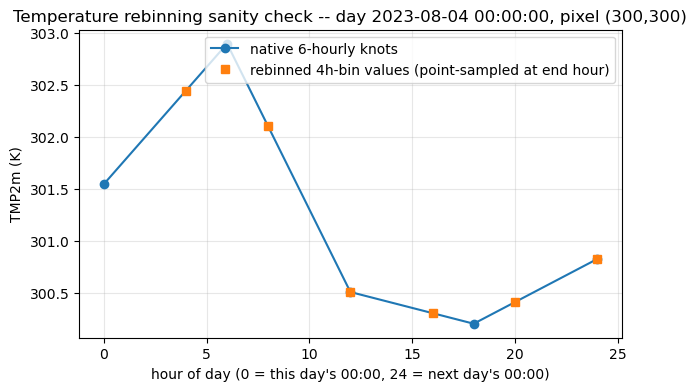

  bin ending  4h: |rebinned - true interpolant value| = 0.00e+00  
  bin ending  8h: |rebinned - true interpolant value| = 0.00e+00  
  bin ending 12h: |rebinned - true interpolant value| = 0.00e+00  (exact copy of a native knot)
  bin ending 16h: |rebinned - true interpolant value| = 0.00e+00  
  bin ending 20h: |rebinned - true interpolant value| = 0.00e+00  
  bin ending 24h: |rebinned - true interpolant value| = 0.00e+00  (exact copy of a native knot)

all 6 bins exact (as expected for point-sampling, unlike the old bin-mean approach) ✓


In [6]:
i_lat, i_lon = 300, 300
day_i = 3  # arbitrary mid-series day

idx = day_start_idx[day_i]
native_hours = np.arange(5) * 6
native_vals = temp_da.isel(time=slice(idx, idx + 5), lat=i_lat, lon=i_lon).values

bin_hours = tbl.BIN_END_HOURS
bin_vals = temp_binned.isel(time=day_i, lat=i_lat, lon=i_lon).values

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(native_hours, native_vals, "o-", label="native 6-hourly knots", color="C0")
ax.plot(bin_hours, bin_vals, "s", label="rebinned 4h-bin values (point-sampled at end hour)", color="C1")
ax.set_xlabel("hour of day (0 = this day's 00:00, 24 = next day's 00:00)")
ax.set_ylabel("TMP2m (K)")
ax.set_title(f"Temperature rebinning sanity check -- day {day_dates[day_i]}, pixel ({i_lat},{i_lon})")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# exact point-sample: every rebinned value should sit exactly on the
# piecewise-linear interpolant through the native knots -- including bins
# 12 and 24, which should be *exact copies* of the native values there
exact_sample = np.interp(bin_hours, native_hours, native_vals)
diff = np.abs(bin_vals - exact_sample)
for h, d in zip(tbl.BIN_END_HOURS, diff):
    exact_knot = h in (12, 24)
    print(f"  bin ending {h:>2}h: |rebinned - true interpolant value| = {d:.2e}  "
          f"{'(exact copy of a native knot)' if exact_knot else ''}")
assert np.allclose(diff, 0, atol=1e-9), "point-sample should be exact everywhere, not just at native knots"
print("\nall 6 bins exact (as expected for point-sampling, unlike the old bin-mean approach) ✓")

## Precipitation: mass-conservation check

The shared `Japan_two_steps_20230101_0000_0600.zarr` demo file only has 2
timesteps (not enough for even one full day + lookahead = 5 knots), so we
build a short **synthetic** 6-hourly rate series here purely to validate
the redistribution end-to-end -- the method itself needs no more than what
`overlap_bin_weights` already validated analytically above; this just
demonstrates it on an (time, ensemble, lat, lon)-shaped array like the real
data, and checks mass conservation numerically rather than by hand.

In [7]:
rng = np.random.default_rng(0)
n_steps = 9  # 2 full days + 1 lookahead step
synthetic_times = pd.date_range("2023-08-01", periods=n_steps, freq="6h")
synthetic_rate = xr.DataArray(
    rng.uniform(0, 2, size=(n_steps, 2, 4, 4)),  # mm/h; (time, ensemble, lat, lon)
    dims=("time", "ensemble", "lat", "lon"),
    coords={"time": synthetic_times, "ensemble": [0, 1]},
    name="PRATEsfc",
)
print(synthetic_rate.dims, synthetic_rate.shape)

precip_binned = tbl.rebin_precip_conservative(synthetic_rate)
print(precip_binned.dims, precip_binned.shape)

# mass check: for each fully-covered day, total accumulated mass (mm) from
# the 6 rebinned 4h bins must equal the total from the 4 native 6h windows
# that feed it (windows ending at 06:00,12:00,18:00, next-day 00:00)
day0_native = synthetic_rate.isel(time=slice(1, 5))          # windows ending 06,12,18,24
day0_native_mass = (day0_native * 6).sum("time")             # mm/h * 6h
day0_binned_mass = (precip_binned.isel(time=0) * 4).sum("bin")  # mm/h * 4h

max_err = float(np.abs(day0_native_mass - day0_binned_mass).max())
print(f"max mass discrepancy over day 0 (all ensemble/lat/lon): {max_err:.2e}")
assert max_err < 1e-10, "mass should be conserved to floating-point precision"
print("mass conserved ✓  (and non-negativity is automatic: a weighted average of non-negative rates)")
print("min value in rebinned output:", float(precip_binned.min()))

('time', 'ensemble', 'lat', 'lon') (9, 2, 4, 4)


('time', 'bin', 'ensemble', 'lat', 'lon') (2, 6, 2, 4, 4)
max mass discrepancy over day 0 (all ensemble/lat/lon): 7.11e-15
mass conserved ✓  (and non-negativity is automatic: a weighted average of non-negative rates)
min value in rebinned output: 0.0006013802138458146


## Why target-duration normalization matters

`overlap_bin_weights` normalizes by **target** bin duration (`W[b] /= (c - a)`
where `(a, c)` are the *target* bin's edges). Normalizing by **source**
window duration instead (an easy mistake -- it still produces a matrix
whose *column* sums are 1, which looks like a valid conservation property)
silently breaks rate/mass consistency whenever source and target durations
differ, as they do here (6h vs 4h). Concrete counterexample: two
consecutive 6h source rates, `[1, 2]` mm/h.

In [8]:
rates = np.array([1.0, 2.0])  # two consecutive 6h windows, ending at hour 6 and 12
src_edges = np.array([0, 6, 12])
tgt_edges = np.array([0, 4, 8, 12])   # three 4h bins spanning the same 12h

W_target_normalized = tbl.overlap_bin_weights(src_edges, tgt_edges)  # what's implemented
W_source_normalized = np.zeros_like(W_target_normalized)
for b, (a, c) in enumerate(zip(tgt_edges[:-1], tgt_edges[1:])):
    for k, (s0, s1) in enumerate(zip(src_edges[:-1], src_edges[1:])):
        overlap = max(0.0, min(c, s1) - max(a, s0))
        W_source_normalized[b, k] = overlap / 6.0   # /src_dur instead of /tgt_dur

true_mass = float((rates * 6).sum())                                    # mm, ground truth
mass_target_norm = float((W_target_normalized @ rates * 4).sum())       # implemented
mass_source_norm = float((W_source_normalized @ rates * 4).sum())       # the bug

print(f"true total mass over 12h:            {true_mass:.2f} mm")
print(f"reconstructed (target-normalized):   {mass_target_norm:.2f} mm  <- what's implemented")
print(f"reconstructed (source-normalized):   {mass_source_norm:.2f} mm  <- loses {(1 - mass_source_norm/true_mass):.0%} of the mass")
assert np.isclose(mass_target_norm, true_mass)
assert not np.isclose(mass_source_norm, true_mass)

true total mass over 12h:            18.00 mm
reconstructed (target-normalized):   18.00 mm  <- what's implemented
reconstructed (source-normalized):   12.00 mm  <- loses 33% of the mass


## Composes directly with `catchment_weighting`

No changes needed there -- `temp_binned`/`precip_binned` still have `time`
plus non-lat/lon dims (`bin`[, `ensemble`]), exactly the shape
`apply_catchment_weights` already expects (it treats any non-lat/lon dim as
pass-through). If cached catchment weights exist from that module's own
notebook run, this applies them directly to a day of rebinned temperature
as an end-to-end check.

In [9]:
from pathlib import Path

weights_cache = Path("../../catchment_weighting/data/hiro_grid_weights.pkl")
if weights_cache.exists():
    sys.path.insert(0, "../../catchment_weighting/scripts")
    import catchment_weighting_lib as cwl

    weights_df = cwl.load_weights(weights_cache)
    basins = cwl.load_basins("/Users/valentin/Desktop/UNRISK/Projects/hydrological_model/Japan_model/data/basins.pkl")

    temp_catchments_binned = cwl.apply_catchment_weights(
        temp_binned, weights_df, lat_dim="lat", lon_dim="lon", polygon_ids=basins.index.values,
    )
    print(temp_catchments_binned.dims, temp_catchments_binned.shape)
    temp_catchments_binned
else:
    print(f"no cached weights at {weights_cache} -- run catchment_weighting.ipynb first to try this end-to-end check")

('time', 'bin', 'catchment_id') (9, 6, 8893)


## Next: the zarr pipeline

`run_temporal_binning.py` does the same rebinning directly against a zarr
store, streamed `--day-chunk` days at a time:

```bash
python run_temporal_binning.py \
    "$TEMP_ZARR" ../data/TMP2m_4hbin.zarr \
    --var TMP2m --method linear

python run_temporal_binning.py \
    "$PRECIP_ZARR" ../data/PRATEsfc_4hbin.zarr \
    --var PRATEsfc --method conservative
```

Its output can then be fed straight into
`catchment_weighting/scripts/run_catchment_weighting.py` as the new
`input_zarr`.